<a href="https://colab.research.google.com/github/srkeyplay/Cinema-Gold/blob/main/Cinema_Gold_(Predictive_Modeling_of_Film_Success).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cinema Gold (Predictive Modeling of Film Success**
> This data project will by guided by the Data Science Methodology by John Rollins.


####**Data Science Methodology by John Rollins:**
>This data science lifecycle is described to have 10 stages.

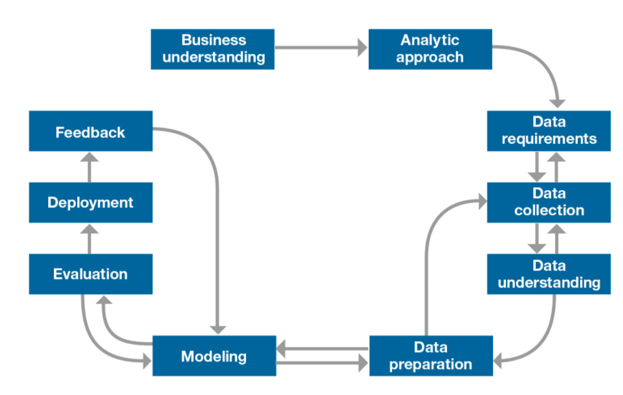

Step 1: Business Understanding (Define the problem, goals and
desired outcome)

Step 2: Analytic Approach ( Determine technical method: Classification, Regression, etc.)

Step: 3: Data Requirements (Determines the data type, sample size, source and storage)

Step: 4: Data Collection (Create data pipline or gathering method)

Step: 5: Data Understanding (Explore quality, relevance and usability/EDA)

Step: 6: Data Preparation (Conduct ETL, Feature Engineering Normalization)

Step: 7: Modeling (Algorithm formation from learned data patterns)

Step: 8: Evaluation (Assess statistical significance, accuracy and success criteria)

Step: 9: Deployment (Make the model accessible or production-ready)

Step: 10: Feedback (Monitor performance and incite continous development)

#####**BUSINESS UNDERSTANDING**
> Define the problem, goals and desired outcome

---
 **Problem:** A movie studio wants to make a movie and wants to predict its best chances of being profitable.

 **Goal:** Create a model that can predict a film's profitablity before its release with a percision of 90%.

 **Questions:**
  1) What makes a movie profitable ? Can we predict a movie's success before it's release ?


#####**ANALYTIC APPROACH**
> Determine technical method: Classification, Regression, etc.

---
**Approach**: Supervised learning method will be used to approach this problem.

Classification and Reggression analysis will be explored to determine the best of the 2 approaches. Supervised method is best to analyse historical movie data and determine wheteher a film is going to be profitable or not.

Classification will determine whether the film will become a success while with the Regression approach the aim is to predict the ROI the unreleased film can produce.



#####**DATA REQUIREMENTS**
> Determines the data type, sample size, source and storage

---
**Data Requirements:**
- Data from a movie database ideally IMDB and TMDB
- CSV file is lightweight file sie and flexiable method for data collection and storage
- data type needed string and int
- Data Points: Title, Genre, Release Year, Budget, Revenue, Profit, Inflation Index and Production Studio




#####**DATA COLLECTION**
> Create data pipline or gathering method

---
Collection Method:

**Kaggle Dataset:** TMDB IMDB Movies Dataset.csv the file is updated on Kaggle daily.

- The movie data from The Movie Database (TMDb) has been sourced from Kaggle, contributed by asaniczka. TMDb provides a comprehensive API with data on movies, TV shows, and more, which is freely available for non-commercial use.

- The IMDb movie data has been sourced from the IMDb Non-Commercial Datasets available at IMDb Non-Commercial Datasets. IMDb provides subsets of movie data for personal and non-commercial use, and this dataset is used with permission from IMDb under their Non-Commercial License. Please refer to IMDb’s terms and conditions for more details on the usage restrictions.


In [1]:
!pip install kagglehub

import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter


In [2]:
#Data Collection Code

#Downloads and saves to a new file
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "ggtejas/tmdb-imdb-merged-movies-dataset", "TMDB  IMDB Movies Dataset.csv")
df.to_csv('RawDataFile.csv', index=False)


/tmp/ipython-input-489664972.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "ggtejas/tmdb-imdb-merged-movies-dataset", "TMDB  IMDB Movies Dataset.csv")


100%|██████████| 266M/266M [00:02<00:00, 97.9MB/s]


#####**DATA UNDERSTANDING**
> Explore quality, relevance and usability/EDA



In [3]:
#Fetch the csv file and load into the dataframe
data = pd.read_csv('RawDataFile.csv')
data.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2799207,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2500174,"Matthew McConaughey, Anne Hathaway, Michael Ca..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3148959,"Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1490615,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1551343,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."


In [4]:
#An overiivew of the size of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436194 entries, 0 to 436193
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    436194 non-null  int64  
 1   title                 436194 non-null  object 
 2   vote_average          436194 non-null  float64
 3   vote_count            436194 non-null  int64  
 4   status                436194 non-null  object 
 5   release_date          414934 non-null  object 
 6   revenue               436194 non-null  int64  
 7   runtime               436194 non-null  int64  
 8   adult                 436194 non-null  bool   
 9   backdrop_path         185215 non-null  object 
 10  budget                436194 non-null  int64  
 11  homepage              54751 non-null   object 
 12  tconst                436194 non-null  object 
 13  original_language     436194 non-null  object 
 14  original_title        436194 non-null  object 
 15  

In [5]:
#An statistical summary of the dataset values
data.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity,averageRating,numVotes
count,4.361940e+05,436194.000000,436194.000000,4.361940e+05,436194.000000,4.361940e+05,436194.000000,436194.000000,4.361940e+05
mean,4.930689e+05,3.600629,48.857187,1.652488e+06,66.462246,6.483609e+05,2.194304,6.230155,3.096902e+03
std,3.632492e+05,3.149687,512.727192,2.618342e+07,63.892587,7.411215e+06,11.343168,1.309341,3.394553e+04
min,2.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000,5.000000e+00
25%,2.099140e+05,0.000000,0.000000,0.000000e+00,15.000000,0.000000e+00,0.600000,5.400000,2.300000e+01
50%,4.189620e+05,4.600000,1.000000,0.000000e+00,80.000000,0.000000e+00,0.855000,6.300000,6.900000e+01
75%,7.102205e+05,6.200000,6.000000,0.000000e+00,96.000000,0.000000e+00,1.658000,7.100000,3.170000e+02
max,1.657538e+06,10.000000,34495.000000,2.923706e+09,14400.000000,8.880000e+08,2994.357000,10.000000,3.170597e+06


In [6]:
#Looking for empty cells
totalnull = data.isnull().sum().sum()
print(totalnull)

data.isnull().sum()


1999509


,0
id,0
title,0
vote_average,0
vote_count,0
status,0
release_date,21260
revenue,0
runtime,0
adult,0
backdrop_path,250979


In [7]:
#How many unique values are present for a column
data.nunique()

,0
id,429307
title,370156
vote_average,4996
vote_count,3598
status,6
release_date,39302
revenue,13553
runtime,559
adult,2
backdrop_path,182789


In [8]:
#dataset displayed and sorted by the higest to lowest revenue
data.sort_values( by='revenue', ascending=False).head(10)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1490615,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
15,299534,Avengers: Endgame,8.263,23857,Released,2019-04-24,2800000000,181,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,...,"Adventure, Science Fiction, Action",Marvel Studios,United States of America,"English, Japanese, Xhosa","superhero, time travel, space travel, time mac...","Anthony Russo, Joe Russo","Christopher Markus, Stephen McFeely, Stan Lee,...",8.4,1434242,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."
282,76600,Avatar: The Way of Water,7.654,9830,Released,2022-12-14,2320250281,192,False,/8rpDcsfLJypbO6vREc0547VKqEv.jpg,...,"Science Fiction, Adventure, Action","20th Century Studios, Lightstorm Entertainment",United States of America,English,"dying and death, loss of loved one, alien life...",James Cameron,"James Cameron, Rick Jaffa, Amanda Silver, Josh...",7.5,605942,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
17,597,Titanic,7.900,23637,Released,1997-11-18,2264162353,194,False,/rzdPqYx7Um4FUZeD8wpXqjAUcEm.jpg,...,"Drama, Romance","Paramount, 20th Century Fox, Lightstorm Entert...",United States of America,"English, French, German, Swedish, Italian, Rus...","epic, ship, drowning, panic, shipwreck, evacua...",James Cameron,James Cameron,8.0,1385616,"Leonardo DiCaprio, Kate Winslet, Billy Zane, K..."
56,140607,Star Wars: The Force Awakens,7.293,18352,Released,2015-12-15,2068223624,136,False,/8BTsTfln4jlQrLXUBquXJ0ASQy9.jpg,...,"Adventure, Action, Science Fiction","Lucasfilm Ltd., Bad Robot",United States of America,English,"android, spacecraft, space opera",J.J. Abrams,"Lawrence Kasdan, J.J. Abrams, Michael Arndt, G...",7.7,1022265,"Harrison Ford, Mark Hamill, Carrie Fisher, Ada..."
6,299536,Avengers: Infinity War,8.255,27713,Released,2018-04-25,2052415039,149,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,...,"Adventure, Action, Science Fiction",Marvel Studios,United States of America,"English, Xhosa","sacrifice, magic, superhero, based on comic, s...","Anthony Russo, Joe Russo","Christopher Markus, Stephen McFeely, Stan Lee,...",8.4,1361219,"Robert Downey Jr., Chris Evans, Chris Hemswort..."
57,634649,Spider-Man: No Way Home,7.990,18299,Released,2021-12-15,1921847111,148,False,/14QbnygCuTO0vl7CAFmPf1fgZfV.jpg,...,"Action, Adventure, Science Fiction","Marvel Studios, Pascal Pictures, Columbia Pict...",United States of America,"English, Tagalog","new york city, hero, showdown, magic, loss of ...",Jon Watts,"Chris McKenna, Erik Sommers, Stan Lee, Steve D...",8.1,1009774,"Tom Holland, Zendaya, Benedict Cumberbatch, Ja..."
44,135397,Jurassic World,6.682,19414,Released,2015-06-06,1671537444,124,False,/dF6FjTZzRTENfB4R17HDN20jLT2.jpg,...,"Action, Adventure, Science Fiction, Thriller","Amblin Entertainment, Universal Pictures",United States of America,English,"island, primal fear, escape, velociraptor, dna...",Colin Trevorrow,"Rick Jaffa, Amanda Silver, Colin Trevorrow, De...",6.9,726455,"Chris Pratt, Bryce Dallas Howard, Irrfan Khan,..."
317,420818,The Lion King,7.100,9325,Released,2019-07-12,1663075401,118,False,/1TUg5pO1VZ4B0Q1amk3OlXvlpXV.jpg,...,"Adventure, Drama, Family","Walt Disney Pictures, Fairview Entertainment",United States of America,English,"africa, lion, prince, redemption, musical, unc...",Jon Favreau,"Jeff Nathanson, Irene Mecchi, Jonathan Roberts...",6.8,290771,"Chiwetel Ejiofor, John Oliver, Donald Glover, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63A

<Axes: xlabel='production_companies'>

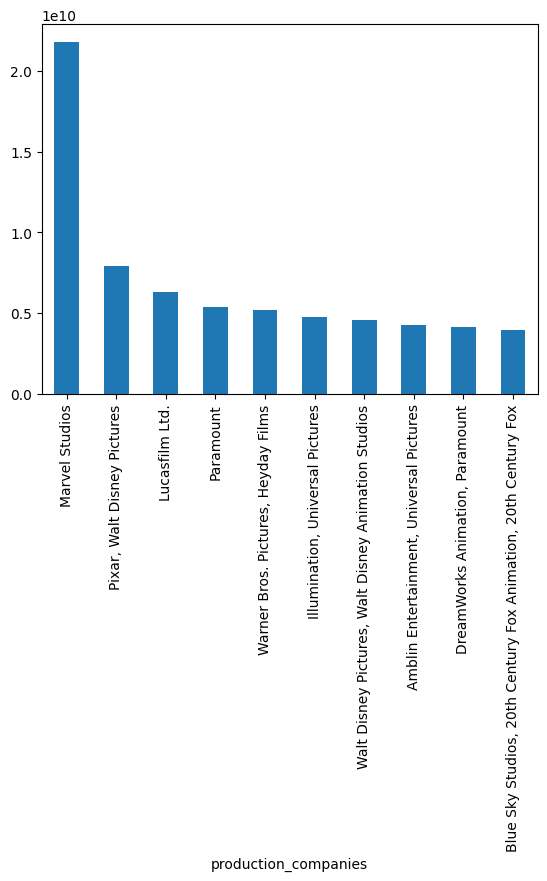

In [9]:
#Top 10 Studios that has the highest Revenue
StudioRevenue = data.groupby('production_companies')['revenue'].sum().sort_values(ascending=False).head(10)
StudioRevenue.plot(kind='bar')

<Axes: xlabel='directors'>

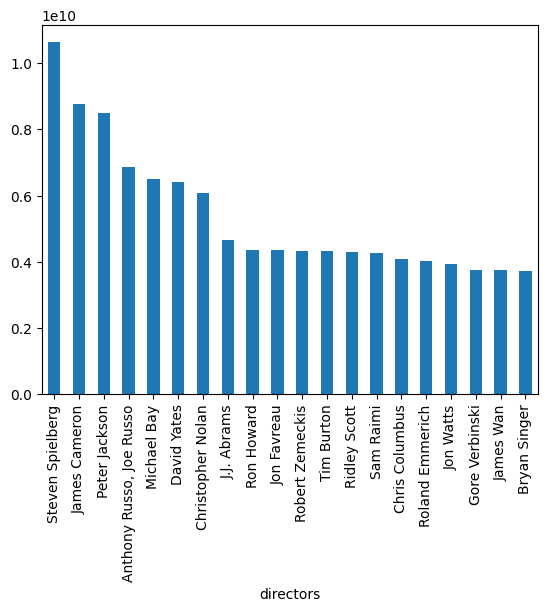

In [11]:
#Top 20 Directors that has the highest Revenue
DirectorsRev = data.groupby('directors')['revenue'].sum().sort_values(ascending=False).head(20)
DirectorsRev.plot(kind='bar')


<Axes: xlabel='directors'>

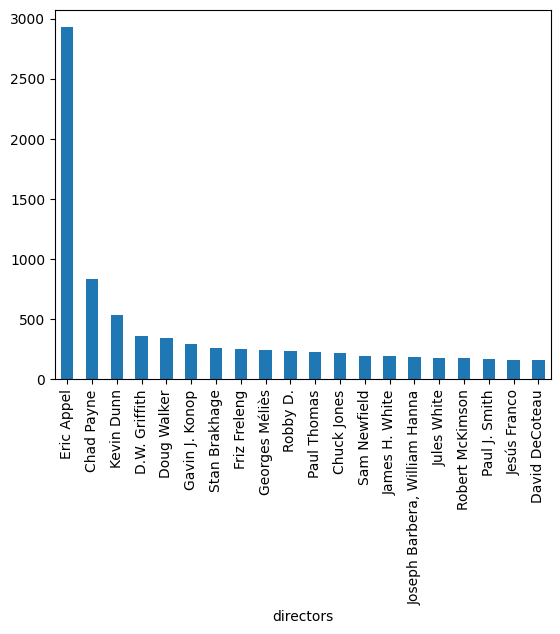

In [12]:
#Top 20 Directors that created the most films
DirectorsFilms = data.groupby('directors')['title'].count().sort_values(ascending=False).head(20)
DirectorsFilms.plot(kind='bar')

<Axes: xlabel='release_date'>

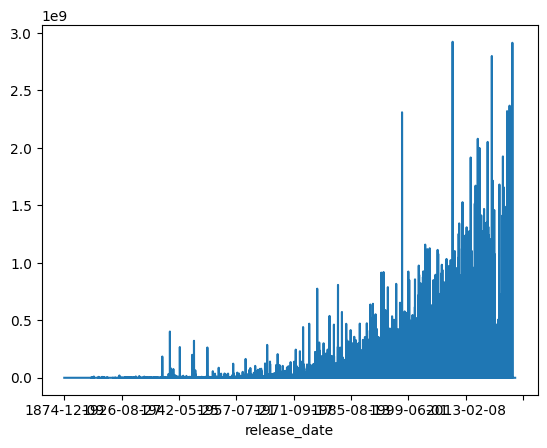

In [13]:
#Revenue generated by year
RevbyYear = data.groupby('release_date')['revenue'].sum()
RevbyYear.plot(kind='line')

<Axes: >

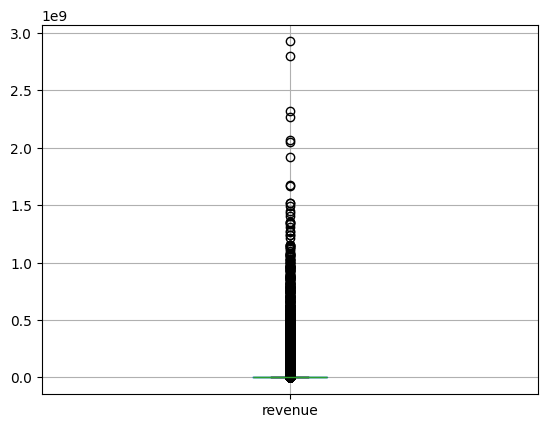

In [14]:
#A box plot of the revenue to identify gaps or outliers
data.boxplot('revenue')

In [15]:
#All the columns that has a numeric datatype is gathered here
NumberColumns = data.select_dtypes(include='number')
NumberColumns.head()

,id,vote_average,vote_count,revenue,runtime,budget,popularity,averageRating,numVotes
0,27205,8.364,34495,825532764,148,160000000,83.952,8.8,2799207
1,157336,8.417,32571,701729206,169,165000000,140.241,8.7,2500174
2,155,8.512,30619,1004558444,152,185000000,130.643,9.1,3148959
3,19995,7.573,29815,2923706026,162,237000000,79.932,7.9,1490615
4,24428,7.710,29166,1518815515,143,220000000,98.082,8.0,1551343


In [16]:
#All the columns that has a non-numeric datatype is gathered here
StringColumns = data.select_dtypes(include='object')
StringColumns.head()

,title,status,release_date,backdrop_path,homepage,tconst,original_language,original_title,overview,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,cast
0,Inception,Released,2010-07-15,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,https://www.warnerbros.com/movies/inception,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate es...",/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W..."
1,Interstellar,Released,2014-11-05,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,http://www.interstellarmovie.net/,tt0816692,en,Interstellar,The adventures of a group of explorers who mak...,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan","Matthew McConaughey, Anne Hathaway, Michael Ca..."
2,The Dark Knight,Released,2008-07-16,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,https://www.warnerbros.com/movies/dark-knight/,tt0468569,en,The Dark Knight,Batman raises the stakes in his war on crime. ...,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...","Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,Avatar,Released,2009-12-15,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,https://www.avatar.com/movies/avatar,tt0499549,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
4,The Avengers,Released,2012-04-25,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,https://www.marvel.com/movies/the-avengers,tt0848228,en,The Avengers,When an unexpected enemy emerges and threatens...,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn","Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."


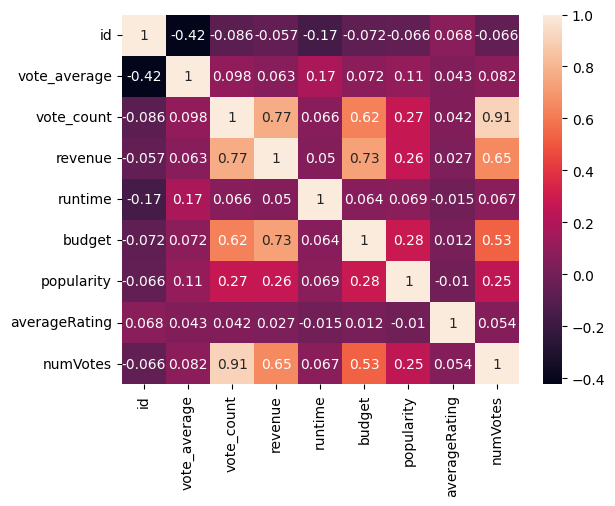

In [17]:
#Generate a heatmap of the correlation between the columns
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

sns.heatmap(NumberColumns.corr(), annot = True)
plt.rcParams['figure.figsize'] = (10,5)
plt.show()

#####**DATA PREPARATION**
> Conduct ETL, Feature Engineering Normalization

In [18]:
#Data Filtering
dataA = data[(data['revenue'] > 0) & (data['budget'] > 0) & (data['directors'].notna()) & (data['production_companies'].notna())& (data['production_countries'].notna()) & (data['release_date'].notna()) & (data['writers'].notna()) & (data['overview'].notna()) & (data['poster_path'].notna()) & (data['spoken_languages'].notna()) & (data['cast'].notna()) & (data['genres'].notna())].copy()

#Dropping these unnecessary columns
dataA = dataA.drop(columns=['id'])
dataA = dataA.drop(columns=['numVotes'])
dataA = dataA.drop(columns=['vote_average'])
dataA = dataA.drop(columns=['backdrop_path'])
dataA = dataA.drop(columns=['homepage'])
dataA = dataA.drop(columns=['tagline'])
dataA = dataA.drop(columns=['keywords'])




In [19]:
#Feature Engineering

#Fix the date format
dataA['release_date'] = pd.to_datetime(dataA['release_date'], errors='coerce')
dataA['release_year'] = dataA['release_date'].dt.year
dataA['release_month'] = dataA['release_date'].dt.month

# Create a "Blockbuster Season" feature
dataA['is_holiday_season'] = dataA['release_month'].isin([6, 7, 11, 12]).astype(int)

#Calculate Profit and ROI
dataA['Profit'] = dataA['revenue'] - dataA['budget']
dataA['ROI'] = (dataA['Profit'] / dataA['budget']) * 100

# Annual Average CPI-U (1913 - 2024)
# Base Year: 1982-1984 = 100
cpi_table = {
    1913: 9.9, 1914: 10.0, 1915: 10.1, 1916: 10.9, 1917: 12.8, 1918: 15.0, 1919: 17.3,
    1920: 20.0, 1921: 17.9, 1922: 16.8, 1923: 17.1, 1924: 17.1, 1925: 17.5, 1926: 17.7,
    1927: 17.4, 1928: 17.2, 1929: 17.2, 1930: 16.7, 1931: 15.2, 1932: 13.6, 1933: 12.9,
    1934: 13.4, 1935: 13.7, 1936: 13.9, 1937: 14.4, 1938: 14.1, 1939: 13.9, 1940: 14.0,
    1941: 14.7, 1942: 16.3, 1943: 17.3, 1944: 17.6, 1945: 18.0, 1946: 19.5, 1947: 22.3,
    1948: 24.0, 1949: 23.8, 1950: 24.1, 1951: 26.0, 1952: 26.6, 1953: 26.8, 1954: 26.9,
    1955: 26.8, 1956: 27.2, 1957: 28.1, 1958: 28.9, 1959: 29.2, 1960: 29.6, 1961: 29.9,
    1962: 30.3, 1963: 30.6, 1964: 31.0, 1965: 31.5, 1966: 32.5, 1967: 33.4, 1968: 34.8,
    1969: 36.7, 1970: 38.8, 1971: 40.5, 1972: 41.8, 1973: 44.4, 1974: 49.3, 1975: 53.8,
    1976: 56.9, 1977: 60.6, 1978: 65.2, 1979: 72.6, 1980: 82.4, 1981: 90.9, 1982: 96.5,
    1983: 99.6, 1984: 103.9, 1985: 107.6, 1986: 109.6, 1987: 113.6, 1988: 118.3, 1989: 124.0,
    1990: 130.7, 1991: 136.2, 1992: 140.3, 1993: 144.5, 1994: 148.2, 1995: 152.4, 1996: 156.9,
    1997: 160.5, 1998: 163.0, 1999: 166.6, 2000: 172.2, 2001: 177.1, 2002: 179.9, 2003: 184.0,
    2004: 188.9, 2005: 195.3, 2006: 201.6, 2007: 207.3, 2008: 215.3, 2009: 214.5, 2010: 218.1,
    2011: 224.9, 2012: 229.6, 2013: 233.0, 2014: 236.7, 2015: 237.0, 2016: 240.0, 2017: 245.1,
    2018: 251.1, 2019: 255.7, 2020: 258.8, 2021: 271.0, 2022: 292.7, 2023: 304.7, 2024: 313.7
}

dataA['release_cpi'] = dataA['release_year'].map(cpi_table)

#Define our "Target" (today's value)
cpi_2024 = 313.7

#Calculate the adjusted values
#Formula: (Original * Target CPI) / Release Year CPI
dataA['adj_revenue'] = (dataA['revenue'] * cpi_2024) / dataA['release_cpi']
dataA['adj_budget'] = (dataA['budget'] * cpi_2024) / dataA['release_cpi']

#Calculate Adjusted Profit
dataA['adj_profit'] = dataA['adj_revenue'] - dataA['adj_budget']

# Calculate ROI (Return on Investment)
# ROI is a percentage: (Profit / Budget) * 100
dataA['adj_roi'] = (dataA['adj_profit'] / dataA['adj_budget']) * 100

import numpy as np

#Normalize Adjust ROI and Budget
dataA['log_adj_roi'] = np.log1p(dataA['adj_roi'] + 100)
dataA['log_adj_budget'] = np.log1p(dataA['adj_budget'])

#Adjust value presentation to millions and add new columns
dataA['adj_revenue_millions'] = dataA['adj_revenue'] / 10000000
dataA['adj_profit_millions'] = dataA['adj_profit'] / 10000000

In [20]:
#One-Hot Encoding genres and Adult| converting categorical data into numberic values
genre_dummies = dataA['genres'].str.get_dummies(sep=', ')
dataA = pd.concat([dataA, genre_dummies], axis=1)


dataA['adult'] = dataA['adult'].replace({True:'For Adults', False:'Not For Adults'})
foradult = dataA['adult'].str.get_dummies()
dataA = pd.concat([dataA, foradult], axis=1)

In [21]:
#Gathering columns with numeric datatype into this dataframe
dataANum = dataA.select_dtypes(include='number')

#Removing least correlated columns to concentrate the highest correlated columns
dataANum = dataANum.drop(columns=['revenue','budget','Profit','ROI','adj_revenue','adj_profit','adj_budget','release_cpi','adj_roi','vote_count'])

#Saving a csv file of the numbers only data and a clean all data file. Making it ideal for the model's prediction off the bat
dataANum.to_csv('Cleaned Movie Values.csv', index=False)

#Saving another with both numbers and non-numeric values
dataA.to_csv('CleanDataFile.csv', index=False)


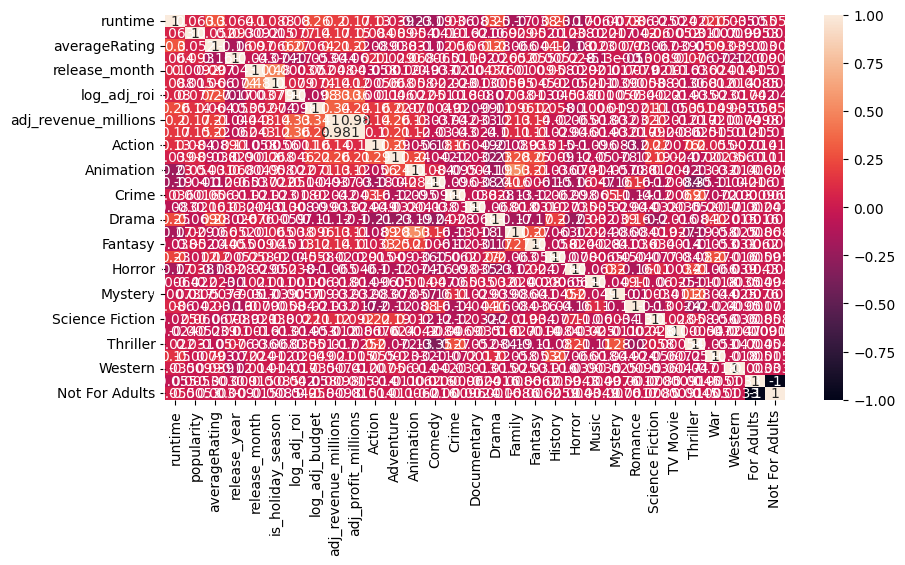

In [22]:
#Reviewing the heatmap correlation of the recenlt cleaned dataset
Numinfo = pd.read_csv('Cleaned Movie Values.csv')
sns.heatmap(Numinfo.corr(), annot = True)
plt.rcParams['figure.figsize'] = (20,20)
plt.show()

In [23]:
#Load the newly cleaned dataset for model use
info = pd.read_csv('CleanDataFile.csv')


#####**MODELLING (Regression Model)**
>The algorithm formation from learned data patterns

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

#Feature Selection (Selecting what the model 'looks' at)
#These are all values that can be determined at a film's pre-release
features = ['log_adj_budget', 'runtime', 'averageRating','release_month', 'release_year','is_holiday_season'] + list(foradult) + list(genre_dummies)
X = info[features]
y = info['log_adj_roi']

#Train-Test Split (The 80/20 Rule)
# The model will be trained on 80% of the data and tested with the remaining 20%.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Training the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)



RandomForestRegressor(random_state=42)

#####**EVALUATION (Regression Model)**
>Assess statistical significance, accuracy and success criteria

Evaluation Metrics:
- Average Prediction Error: $1.10 Million
- Accuracy Score (R2): 0.25


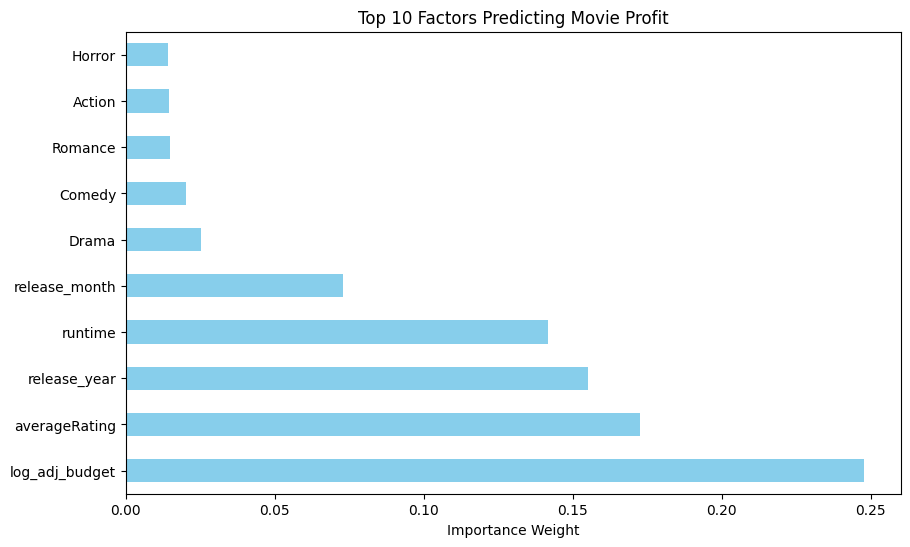

In [25]:
#Evaluation (The Report Card)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Evaluation Metrics:")
print(f"- Average Prediction Error: ${mae:.2f} Million")
print(f"- Accuracy Score (R2): {r2:.2f}")

#Feature Importance Visualization
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False).head(10)
importances.plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Top 10 Factors Predicting Movie Profit')
plt.xlabel('Importance Weight')
plt.show()

#####**MODELLING (Classification Model)**
>Algorithm formation from learned data patterns

In [26]:
#Create the Success Label (1 = Hit, 0 = Flop)
#A hit is determined by investment being doubled and represented by ROI being at 100%
info['is_hit'] = (info['adj_roi'] > 100).astype(int)

#Check the "Class Balance"
print(info['is_hit'].value_counts(normalize=True))


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#Use the same features as used with the regression model with the target 'id_hit' being specific for this model
X2 = info[features]
y2 = info['is_hit']

#Train-Test Split (The 80/20 Rule)
#The model will be trained on 80% of the data and tested with the remaining 20%.
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

#Initialize the Classifier instead of Regressor
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train, y_train)


is_hit
0    0.531789
1    0.468211
Name: proportion, dtype: float64


RandomForestClassifier(random_state=42)

#####**EVALUATION (Classification Model)**
>Assess statistical significance, accuracy and success criteria

In [27]:
#Evaluate
clf_preds = clf_model.predict(X_test)
print(f"Classification Accuracy: {accuracy_score(y_test, clf_preds):.2f}")

Classification Accuracy: 0.68


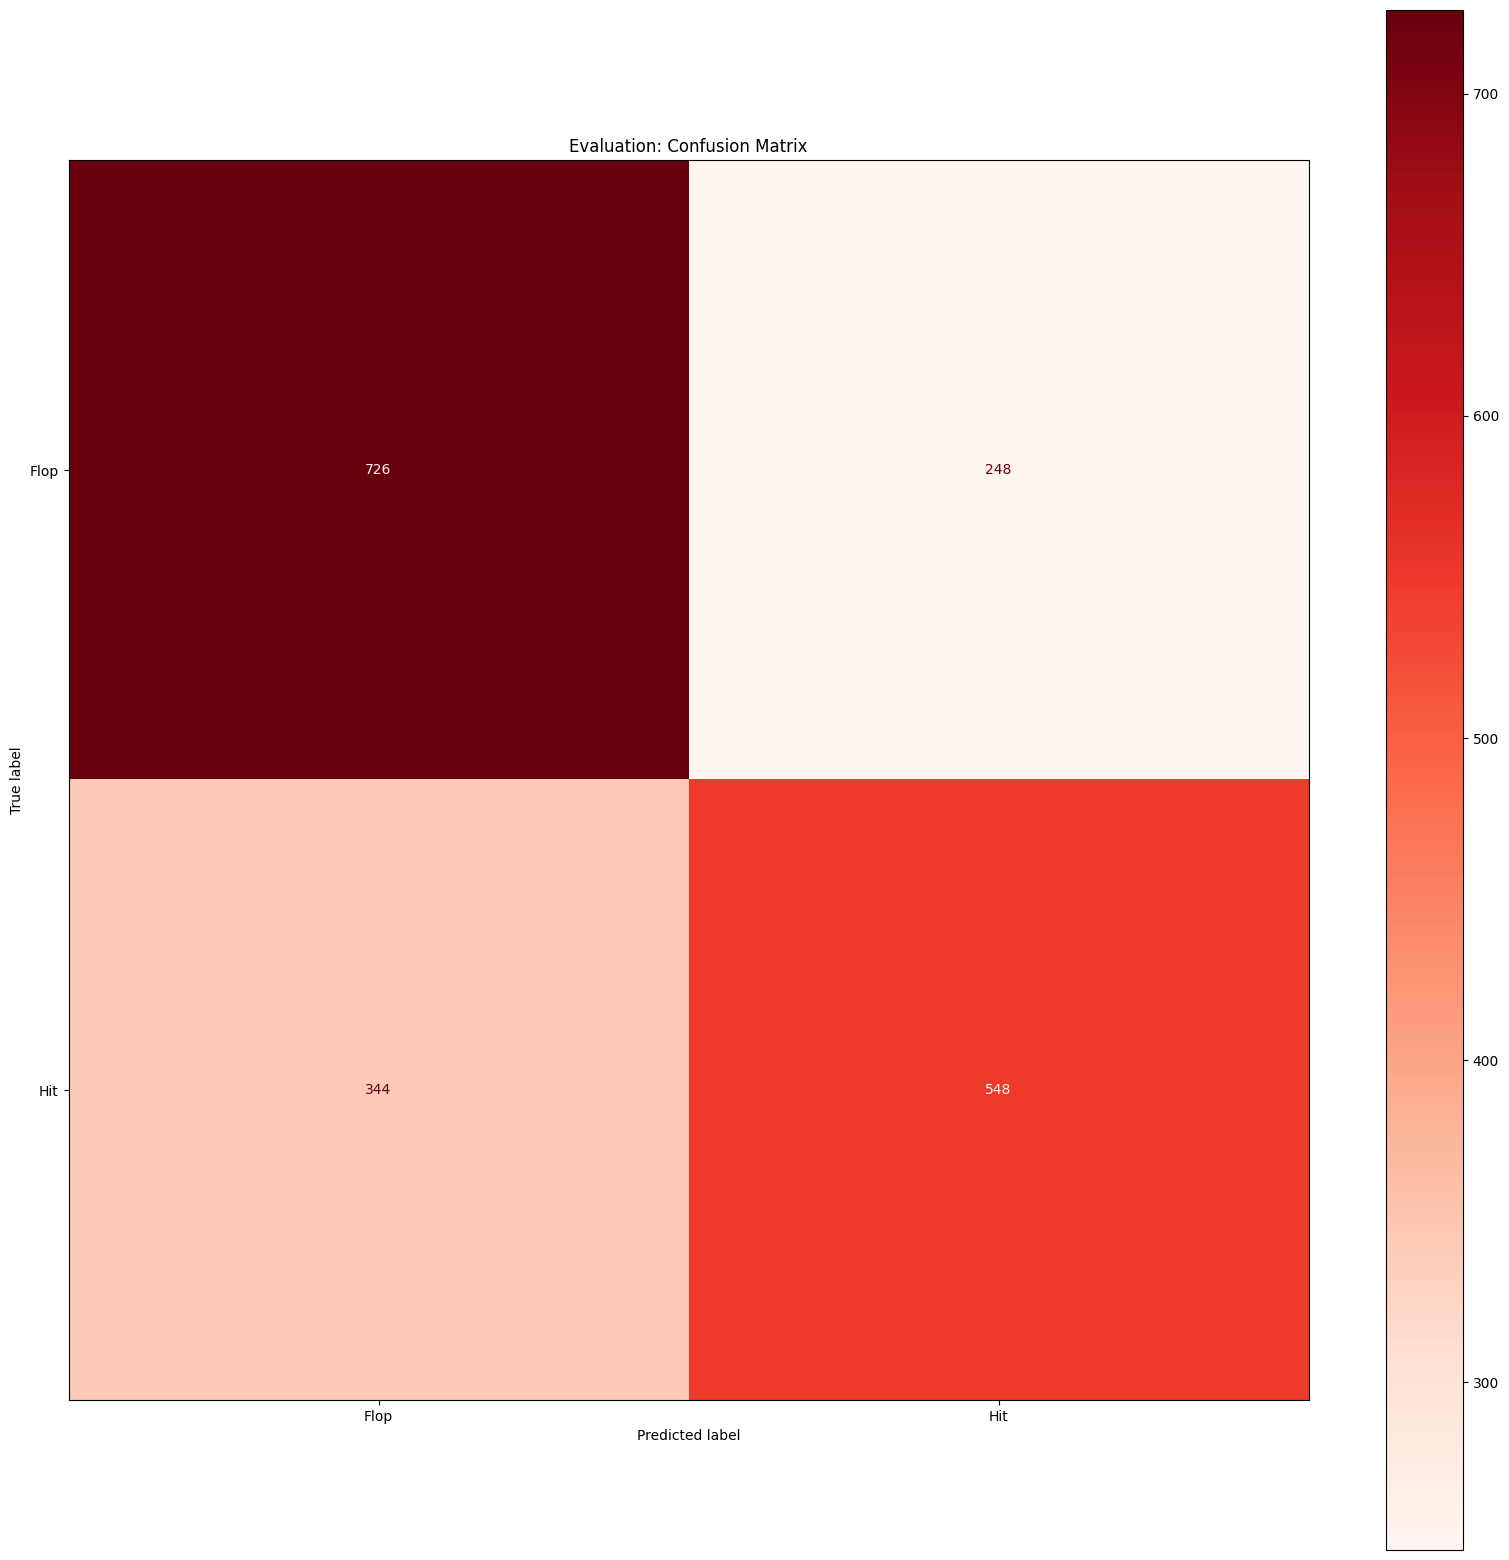

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Generate the matrix
cm = confusion_matrix(y_test, clf_preds)

#Display the Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Flop', 'Hit'])
disp.plot(cmap='Reds')
plt.title('Evaluation: Confusion Matrix')
plt.show()

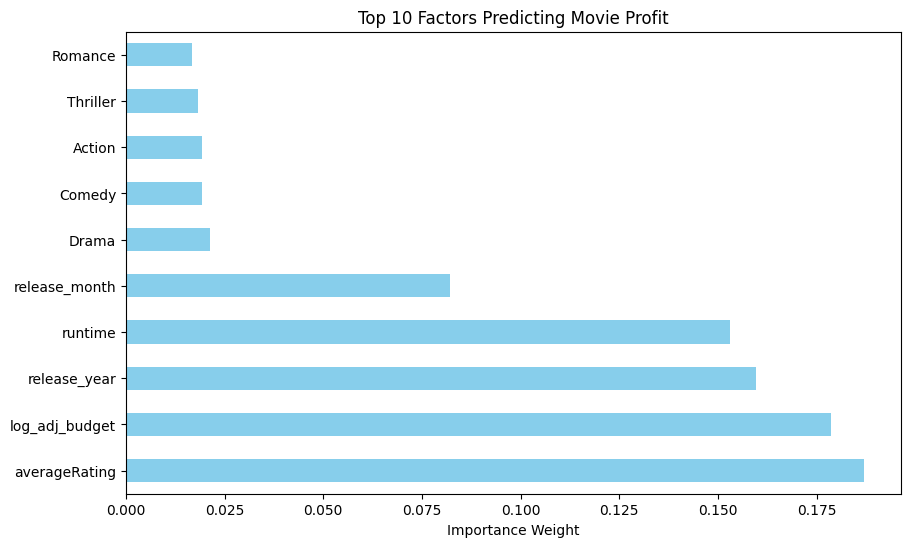

In [29]:
#Feature Importance Visualization
importances = pd.Series(clf_model.feature_importances_, index=features).sort_values(ascending=False).head(10)
importances.plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Top 10 Factors Predicting Movie Profit')
plt.xlabel('Importance Weight')
plt.show()

#####**DEPLOYMENT**
>Make the model and the findings accessible or production-ready

1) What makes a movie profitable ? Can we predict a movie's success before it's release ?

2) Top 10 movies with the highest profit median of all time ?

3) Top 10 production/movie studio has the highest profit median ?

4) Top 10 movie genres that has the highest revenue median ?

5) Which 5 movie genres on average generates the highest ROI ?

6) Which movies genres are the most popular ?

7) Which movies studio invest the most in their films what is their average ROI ? and Which movie studio invest the least in their films, what is their avaerage ROI ?

/tmp/ipython-input-1240500673.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_movies.values, y=top_movies.index, ax=axes[0,0], palette="Reds_r")
/tmp/ipython-input-1240500673.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_movies.values, y=top_movies.index, ax=axes[0,1], palette="Reds_r")
/tmp/ipython-input-1240500673.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_studios.values, y=top_studios.index, ax=axes[0,2], palette="Purples_r")
/tmp/ipython-input-1240500673.py:41: FutureWarning: 

Passing `palette` wit

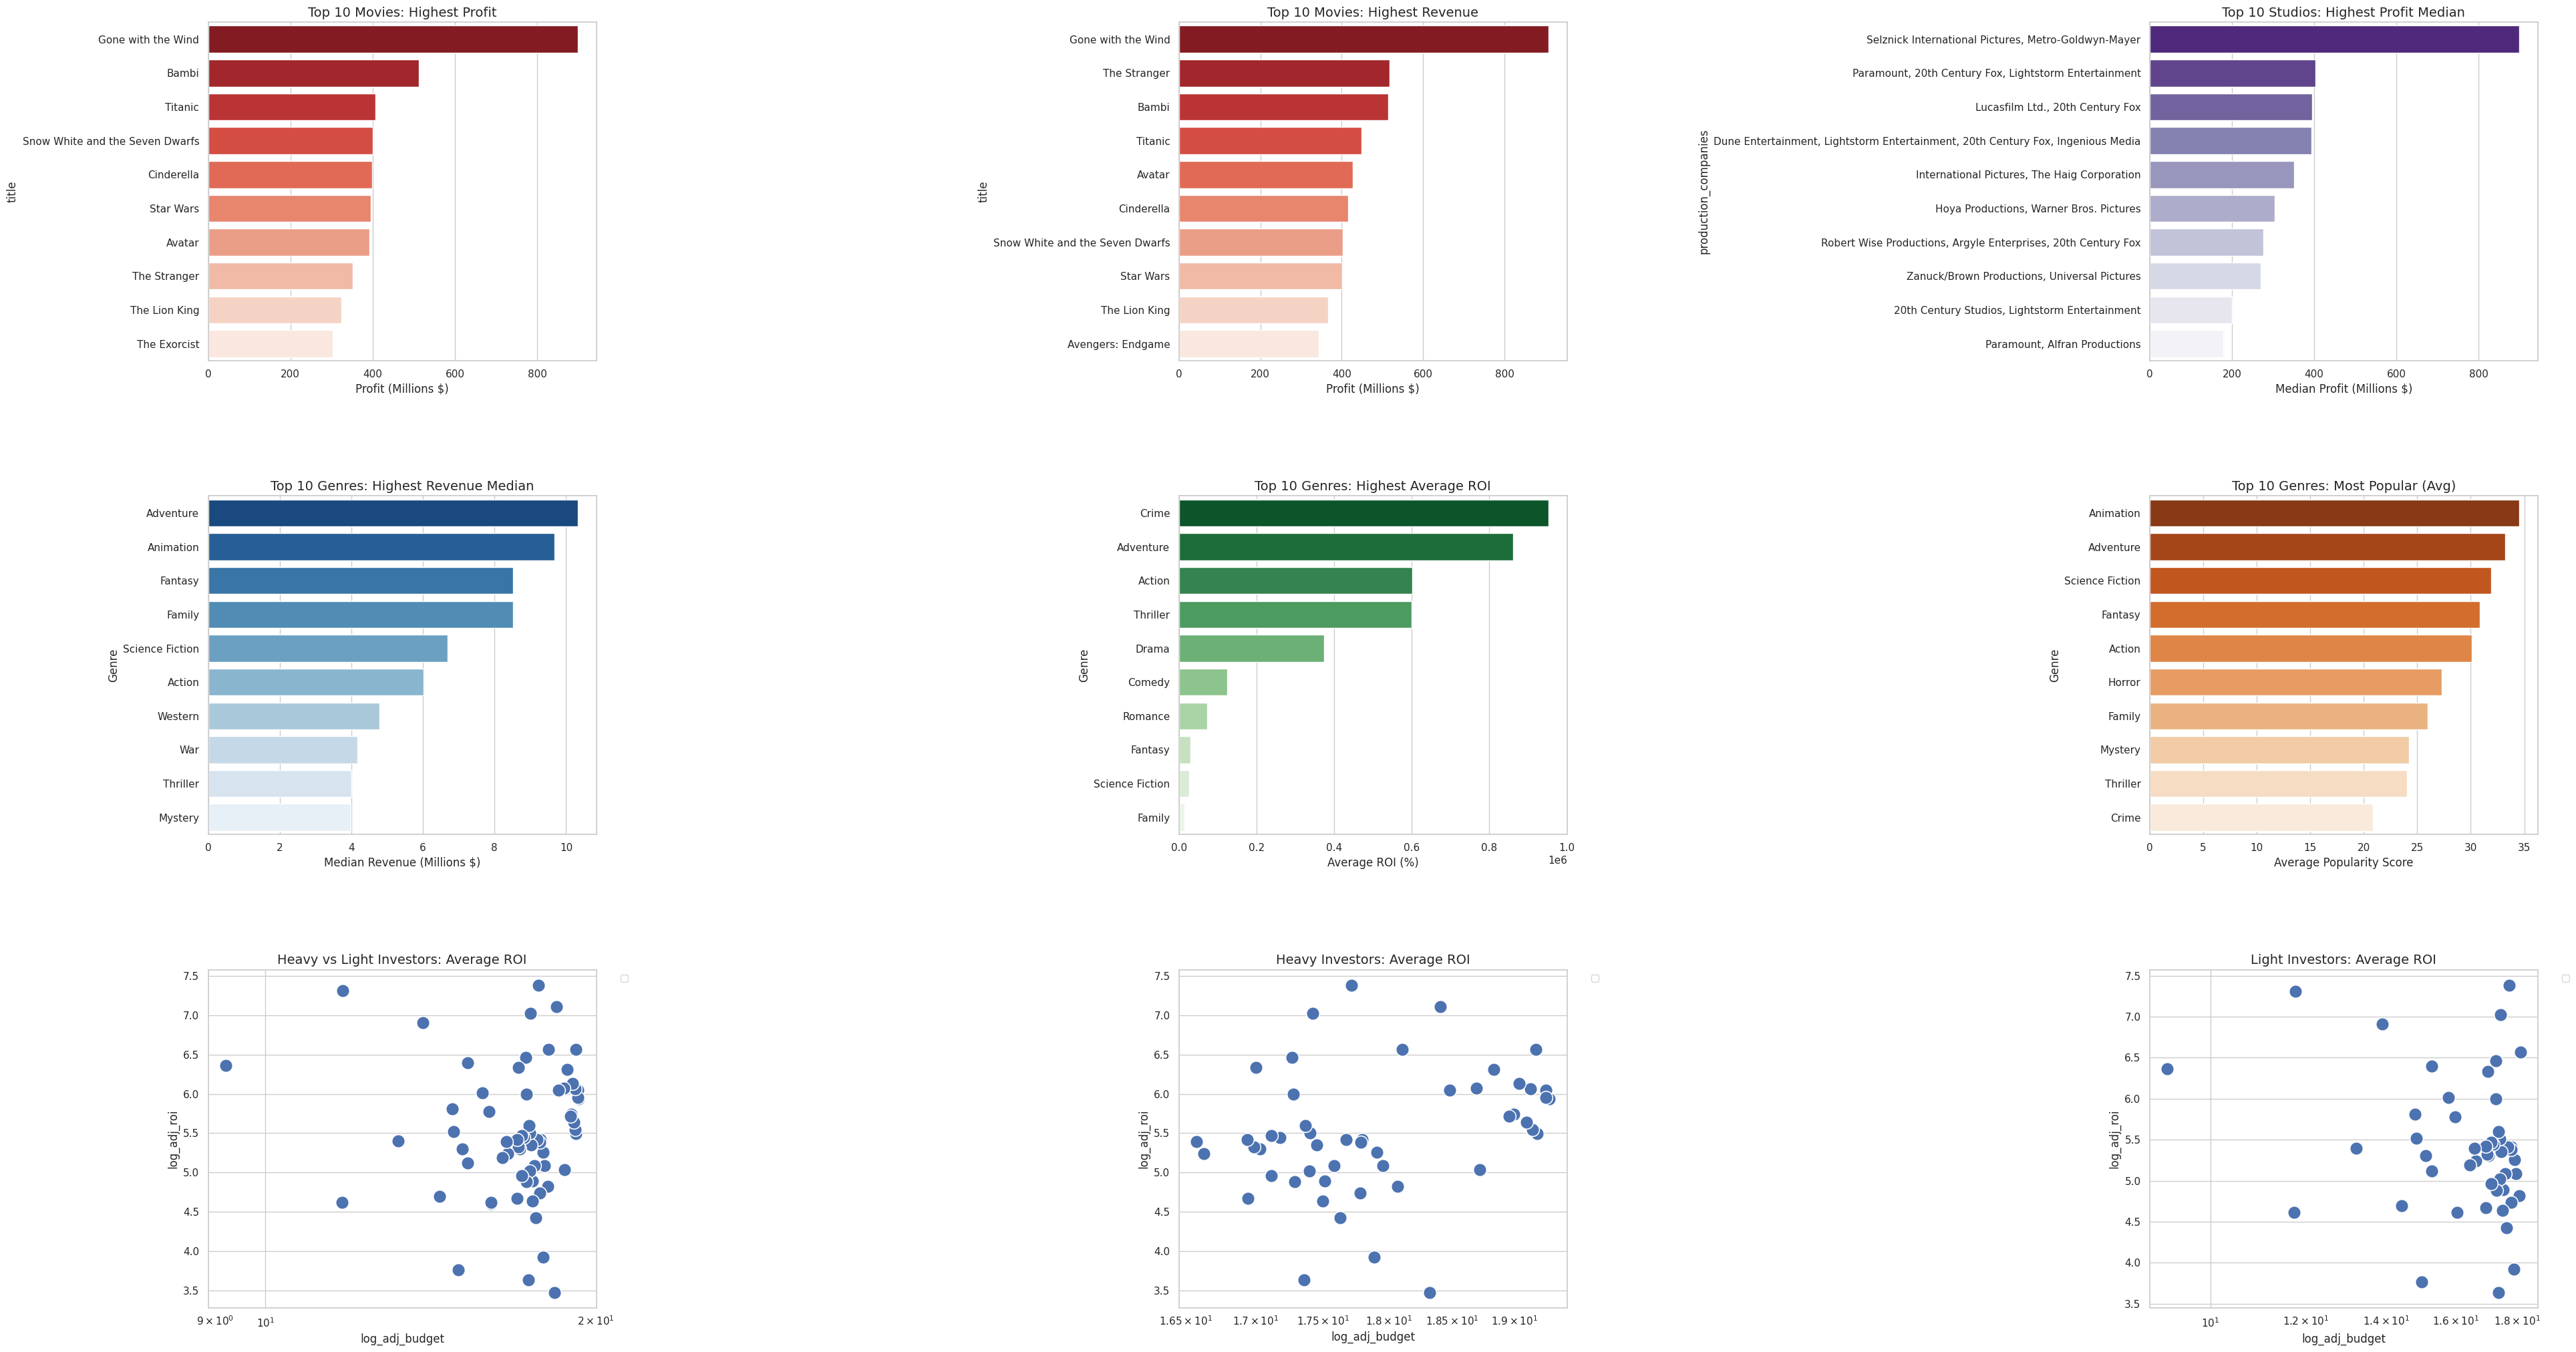

In [36]:
# Set style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(45, 25))
plt.subplots_adjust(hspace=0.4, wspace=1.5)

#Top 10 Movies by Profit
# (Grouping by title to handle remakes/re-releases)
top_movies = info.groupby('title')['adj_profit_millions'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_movies.values, y=top_movies.index, ax=axes[0,0], palette="Reds_r")
axes[0,0].set_title('Top 10 Movies: Highest Profit', fontsize=14)
axes[0,0].set_xlabel('Profit (Millions $)')

#Top 10 Movies by Profit
# (Grouping by title to handle remakes/re-releases)
top_movies = info.groupby('title')['adj_revenue_millions'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_movies.values, y=top_movies.index, ax=axes[0,1], palette="Reds_r")
axes[0,1].set_title('Top 10 Movies: Highest Revenue', fontsize=14)
axes[0,1].set_xlabel('Profit (Millions $)')

#Top 10 Studios by Profit Median
top_studios = info.groupby('production_companies')['adj_profit_millions'].median().sort_values(ascending=False).head(10)
sns.barplot(x=top_studios.values, y=top_studios.index, ax=axes[0,2], palette="Purples_r")
axes[0,2].set_title('Top 10 Studios: Highest Profit Median', fontsize=14)
axes[0,2].set_xlabel('Median Profit (Millions $)')

# --- Prep for Genre Questions (4, 5, 6) ---
genre_list = list(genre_dummies.columns)
genre_data = []
for genre in genre_list:
    subset = info[info[genre] == 1]
    genre_data.append({
        'Genre': genre,
        'Median_Revenue': subset['adj_revenue_millions'].median(),
        'Avg_ROI': subset['adj_roi'].mean(),
        'Avg_Popularity': subset['popularity'].mean()
    })
genre_results = pd.DataFrame(genre_data)

#Top 10 Genres by Revenue Median ---
top_rev_genre = genre_results.sort_values('Median_Revenue', ascending=False).head(10)
sns.barplot(x='Median_Revenue', y='Genre', data=top_rev_genre, ax=axes[1,0], palette="Blues_r")
axes[1,0].set_title('Top 10 Genres: Highest Revenue Median', fontsize=14)
axes[1,0].set_xlabel('Median Revenue (Millions $)')

#Top 5 Genres by Average ROI ---
top_roi_genre = genre_results.sort_values('Avg_ROI', ascending=False).head(10)
sns.barplot(x='Avg_ROI', y='Genre', data=top_roi_genre, ax=axes[1,1], palette="Greens_r")
axes[1,1].set_title('Top 10 Genres: Highest Average ROI', fontsize=14)
axes[1,1].set_xlabel('Average ROI (%)')

#Most Popular Genres ---
pop_genre = genre_results.sort_values('Avg_Popularity', ascending=False).head(10)
sns.barplot(x='Avg_Popularity', y='Genre', data=pop_genre, ax=axes[1,2], palette="Oranges_r")
axes[1,2].set_title('Top 10 Genres: Most Popular (Avg)', fontsize=14)
axes[1,2].set_xlabel('Average Popularity Score')

# ---Studio Investment vs ROI ---
# Find Highest and Lowest average spenders
studio_invest = info.groupby('production_companies').agg({'log_adj_budget': 'median', 'log_adj_roi': 'median'}).reset_index()

# Filter for studios with at least 4 movies to avoid "one-hit wonders"
studio_counts = info['production_companies'].value_counts()
major_studios = studio_invest[studio_invest['production_companies'].isin(studio_counts[studio_counts >= 5].index)]


heavyInvest = pd.concat([major_studios.sort_values('log_adj_budget', ascending=False).head(50)]) # Top 50 spenders
lightInvest = pd.concat([major_studios.sort_values('log_adj_budget', ascending=False).tail(50)])  # Bottom 50 spenders

extreme_investors = pd.concat([heavyInvest,lightInvest])

sns.scatterplot(x='log_adj_budget', y='log_adj_roi', data=extreme_investors, s=200, ax=axes[2,0])
axes[2,0].set_xscale('log')
axes[2,0].set_title('Heavy vs Light Investors: Average ROI', fontsize=14)
axes[2,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')


sns.scatterplot(x='log_adj_budget', y='log_adj_roi', data=heavyInvest, s=200, ax=axes[2,1])
axes[2,1].set_xscale('log')
axes[2,1].set_title('Heavy Investors: Average ROI', fontsize=14)
axes[2,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

sns.scatterplot(x='log_adj_budget', y='log_adj_roi', data=lightInvest, s=200, ax=axes[2,2])
axes[2,2].set_xscale('log')
axes[2,2].set_title('Light Investors: Average ROI', fontsize=14)
axes[2,2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')


plt.show()

/tmp/ipython-input-893644751.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis', ax=axes[1])


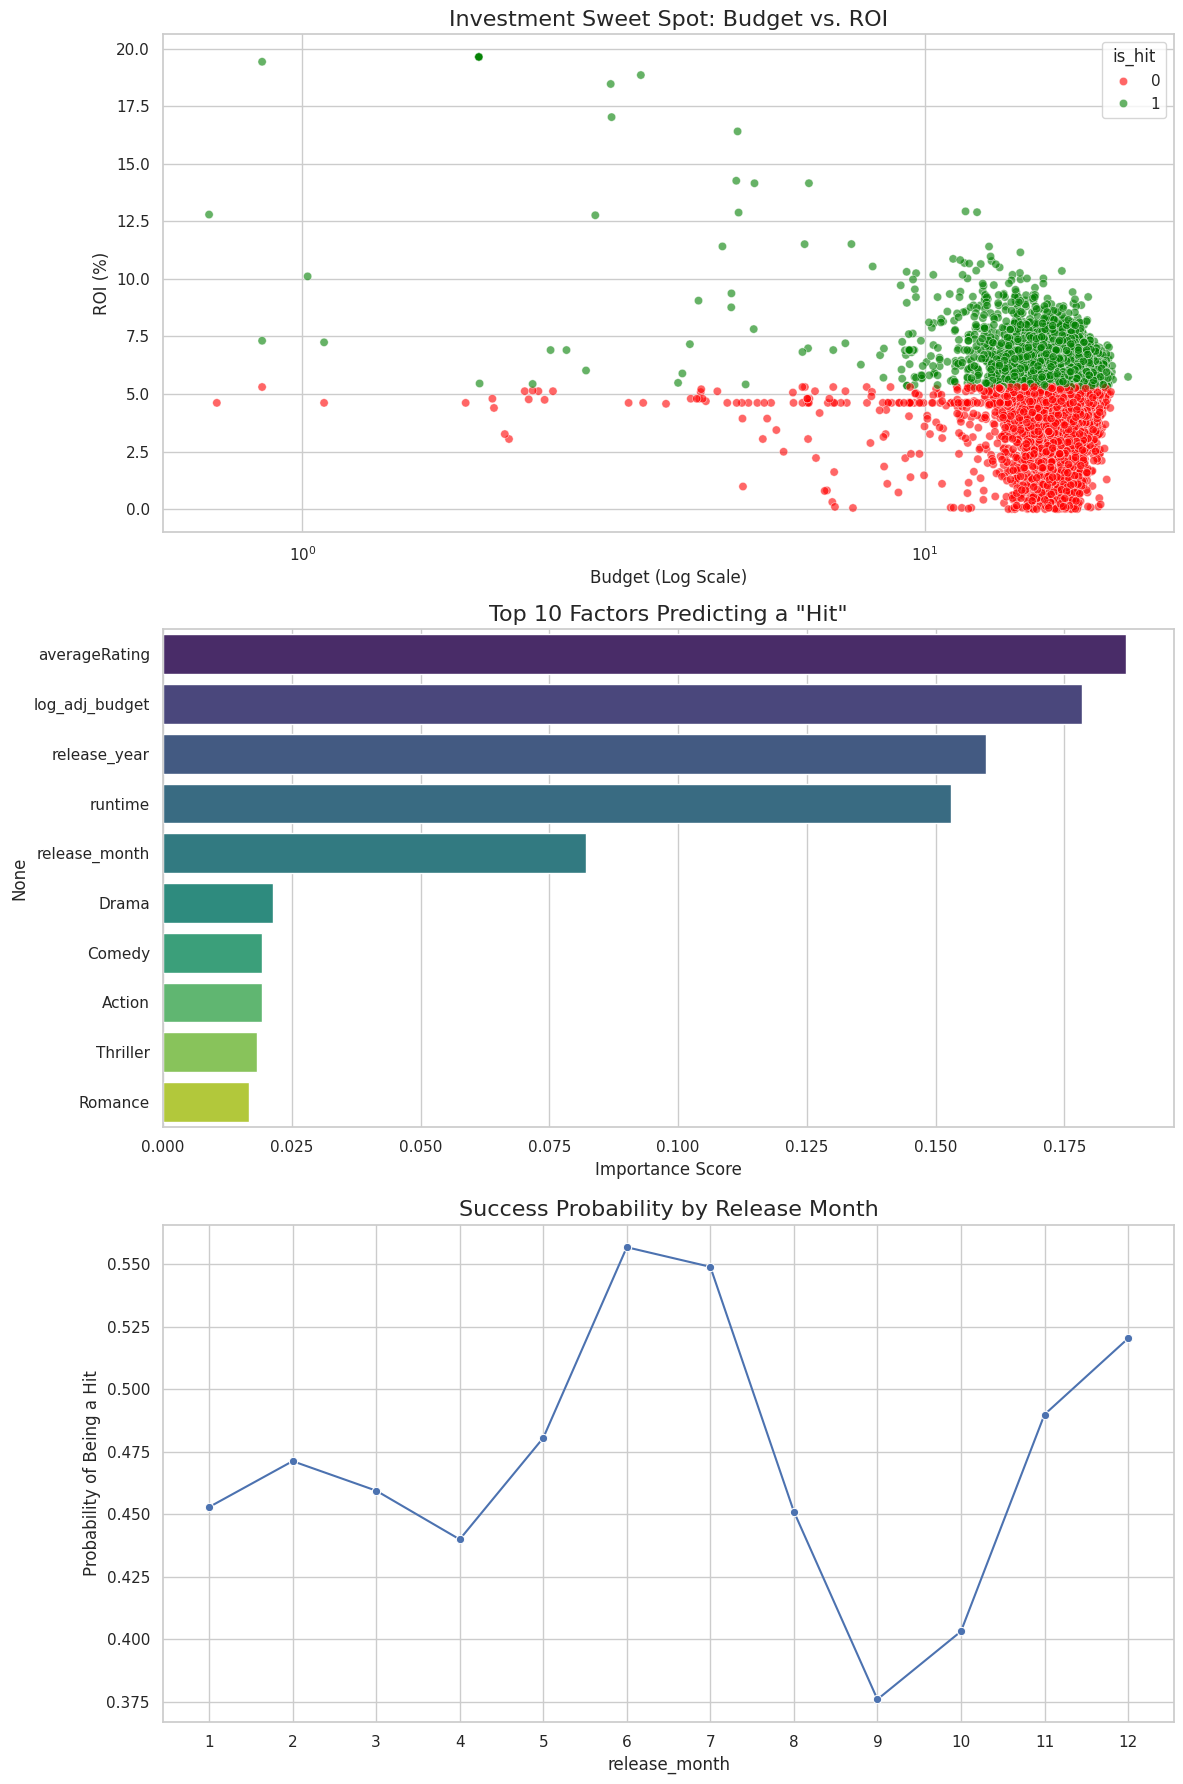

In [31]:

# Set the theme
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# --- Top Drivers of Success (Feature Importance) ---
importances = pd.Series(clf_model.feature_importances_, index=features).sort_values(ascending=False).head(10)
sns.barplot(x=importances.values, y=importances.index, palette='viridis', ax=axes[1])
axes[1].set_title('Top 10 Factors Predicting a "Hit"', fontsize=16)
axes[1].set_xlabel('Importance Score', fontsize=12)

# --- Budget vs ROI (The "Sweet Spot") ---
sns.scatterplot(data=info, x='log_adj_budget', y='log_adj_roi', hue='is_hit',
                palette={1: 'green', 0: 'red'}, alpha=0.6, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Investment Sweet Spot: Budget vs. ROI', fontsize=16)
axes[0].set_xlabel('Budget (Log Scale)', fontsize=12)
axes[0].set_ylabel('ROI (%)', fontsize=12)


# --- Seasonal Success Probability ---
monthly_success = info.groupby('release_month')['is_hit'].mean().reset_index()
sns.lineplot(data=monthly_success, x='release_month', y='is_hit', marker='o', ax=axes[2])
axes[2].set_title('Success Probability by Release Month', fontsize=16)
axes[2].set_xticks(range(1, 13))
axes[2].set_ylabel('Probability of Being a Hit', fontsize=12)

plt.tight_layout()
plt.show()

#####**FEEDBACK**
>Monitor performance and incite continous development

Our goal was to achieve 90% accuracy with our predictive model. Our regression model came up way short with an accuracy of 27% and an average prediction error of $1.10 million. It was a difficult task for the model to predict the exact ROI value. The issue isn’t the quality of the data nor the quantity though increasing the quantity would improve the accuracy by giving the model more films to learn from.

Our classification model was a better performer and a closer reflection of the film industry’s volatile nature. An accuracy of 69% predicting a hit or flop film.

When we take a look at the film’s budget vs the ROI I can almost say it's a gamble but I won’t because there are more features that can be taken into consideration such as the marketing budget, script & film critic sentiment analysis, the global distribution network and competitor analysis (which other films are sharing the same release period). If I got my hands on this data then we would be looking at a much improved predictive model giving the film executives much more confidence to make decisions on greenlighting a film project.
I found out what makes a film successful from the current dataset but there is much more to it. My classification model got me close to the desired 90% accuracy but that may not be possible given that humans may be habitual but still unpredictable given the unlimited input or influences globally.

As it stands now, what we have is a tool that can set the business foundation for success regarding the film’s genre, runtime, release month and budget. The rest is dependent on the creative process and the audience's subjective response to it. This model will give the decision makers the confidence to put all they can in place on the business side giving the creatives the best chance of carrying the film to a success.

This is by setting the film release dates for June, July, November or December, deciding on a runtime suitable to tell the story at hand while setting expectations for the genre being developed and how much effort is needed for chances of creating a hit.

I conclude that while we use math to help us understand the world around us and A.I. using this math to get things done, without human autonomy, curiosity and creativity the tool just sits there. The math has shown us that while some figures and its relationship to others may be constant, the human factor isn’t objective. I didn’t achieve a 90% accuracy but 69% seems to account for the unquantifiable subjective nature of art that is films and humans the audience.
